In [74]:
# Importing Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [75]:
# Importing Dataset
df = pd.read_csv("Walmart DataSet.csv")

In [76]:
# Checking dataset
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [77]:
# Checking for null values
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [78]:
#Checking for Datatypes of columns , number of columns and shape of data
df.info()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB
(6435, 8)


#### No null values from above result and visual inspection
#### date is not in datetime format

In [79]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [80]:
# Checking for duplicated data
df.duplicated().sum()

0

##### No duplicated data found

#### Now that the data is clear from any unwanted entries, 
### Performing EDA

In [81]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


<Axes: >

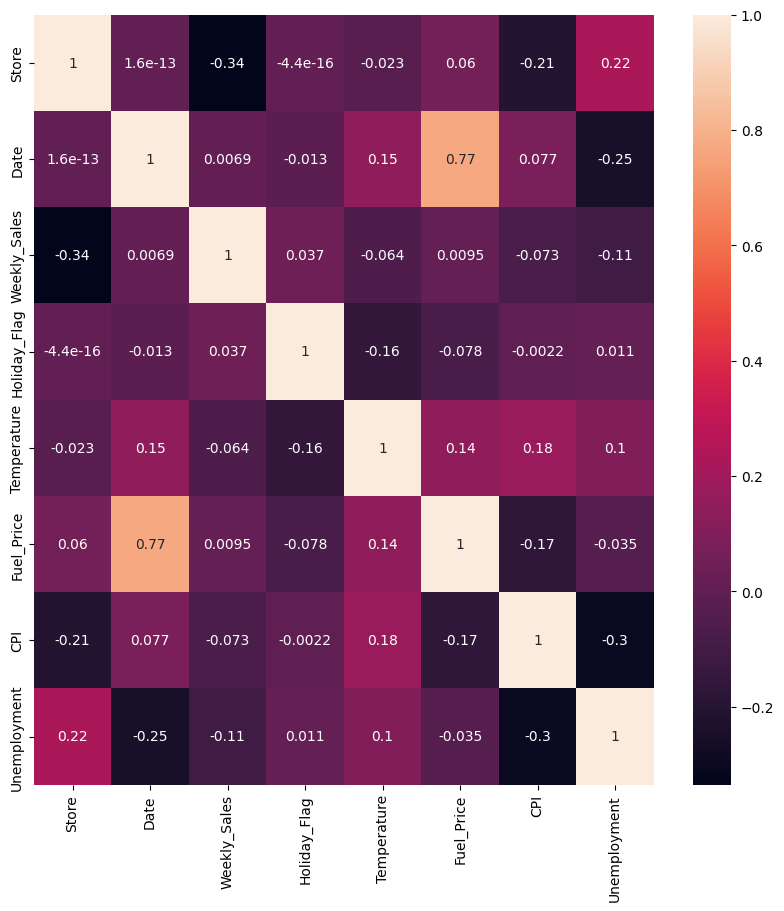

In [82]:
plt.figure (figsize=(10,10))
sns.heatmap(df.corr(),annot=True)

##### -	There’s not much multicolliearity in the data so no need to drop any columns.

### Visualizing Dataset

In [83]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667


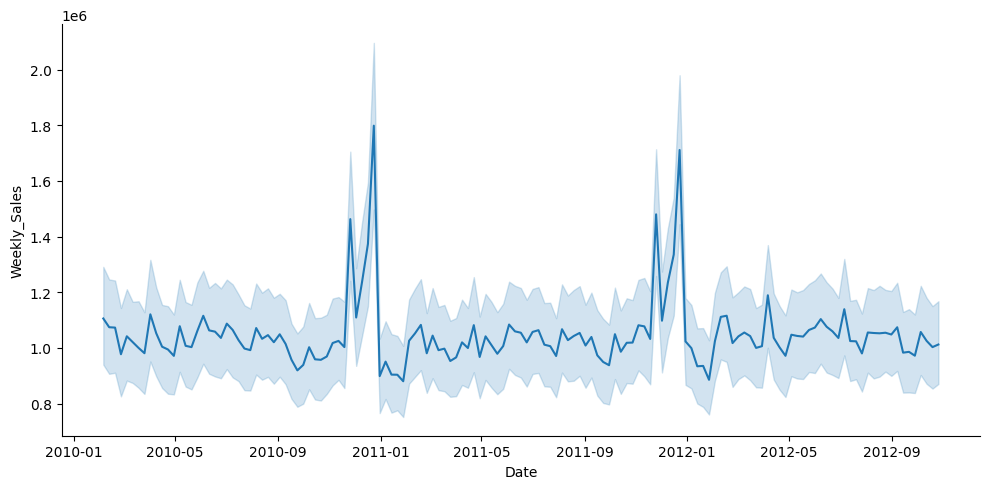

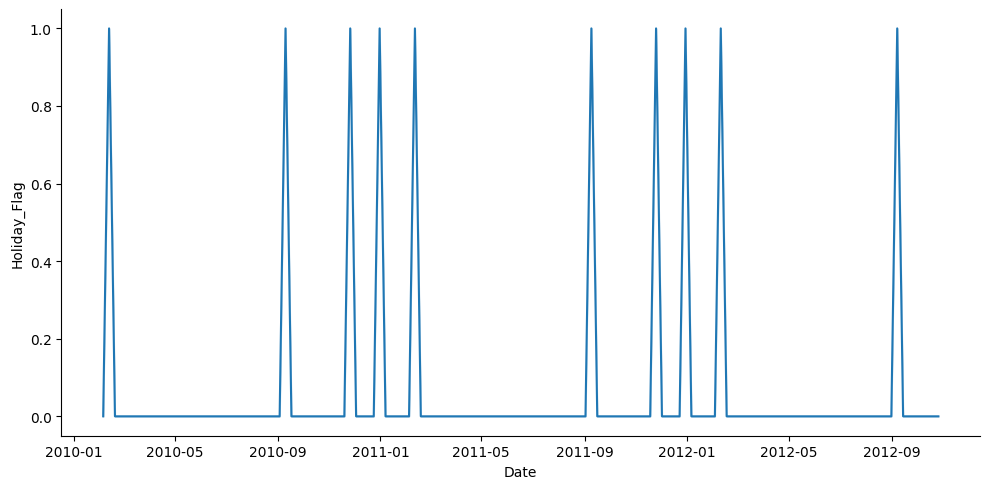

In [84]:
sns.relplot(data=df,x=df['Date'],y=df['Weekly_Sales'],kind='line',height=5,aspect = 2)
sns.relplot(data=df,x=df['Date'],y=df['Holiday_Flag'],kind='line',height=5,aspect = 2)

### We can see seasonality trend on weekly sales as sales hike at the end of every year and the major reason for that is the Holiday season.

<Axes: title={'center': 'Total sales for each store'}, xlabel='Store', ylabel='Total Sales'>

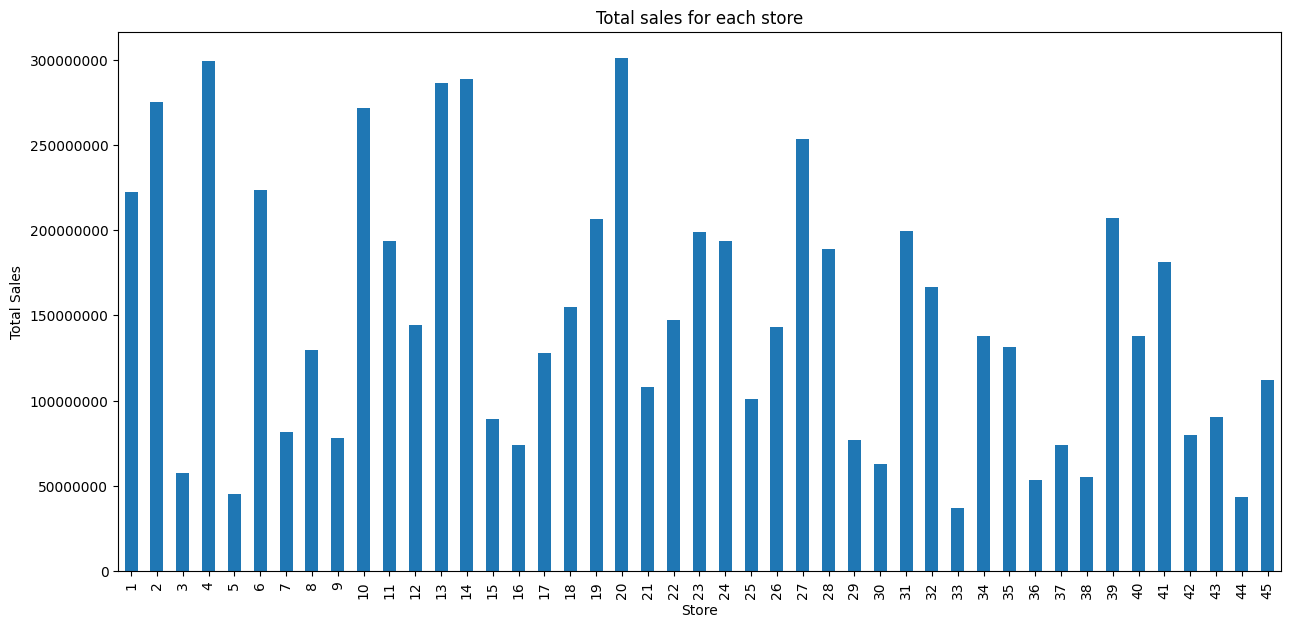

In [85]:
total_sales = df.groupby('Store')['Weekly_Sales'].sum()
total_sales_array = np.array(total_sales)
plt.figure(figsize=(15,7))
plt.xticks(rotation=0)
plt.ticklabel_format(useOffset=False, style='plain', axis='y')
plt.title('Total sales for each store')
plt.xlabel('Store')
plt.ylabel('Total Sales')
total_sales.plot(kind='bar')


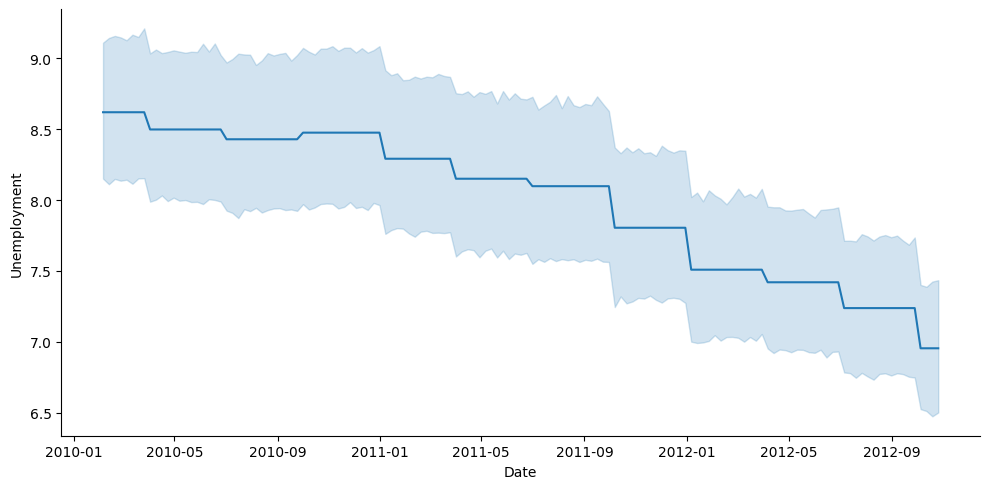

In [86]:
sns.relplot(data=df,x=df['Date'],y=df['Unemployment'],kind='line',height=5,aspect=2)

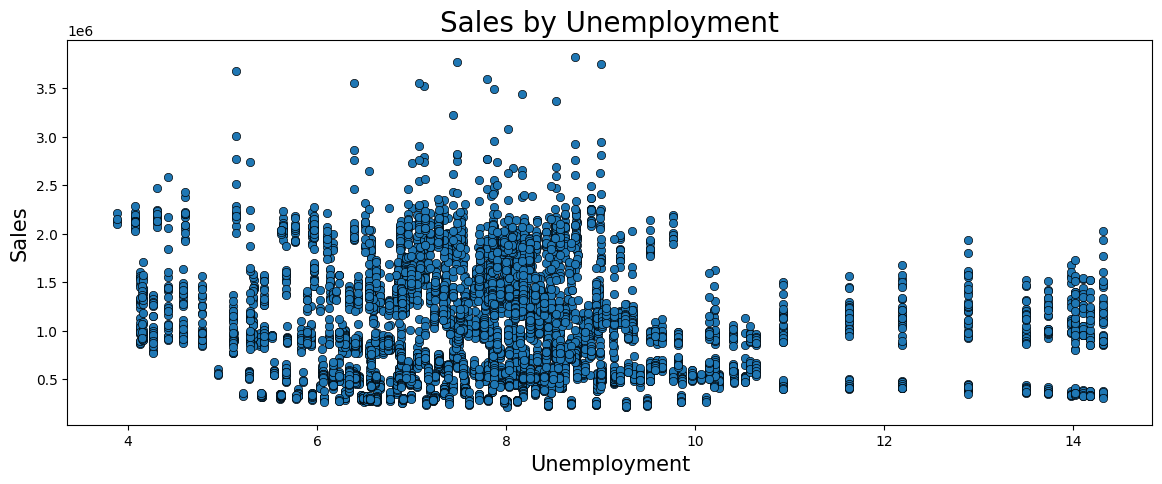

In [87]:
plt.figure(figsize = (14, 5))
sns.scatterplot(data = df,
                x = 'Unemployment',
                y = 'Weekly_Sales',
                edgecolor = "black")

# Add labels and title
plt.title('Sales by Unemployment', size = 20)
plt.xlabel('Unemployment', size = 15)
plt.ylabel('Sales', size = 15)
plt.show()

In [88]:
# Separate each store from the Dataframe into dictionary of dataframes
Store = {}
store_numbers=list(df['Store'].unique())
for i in range(1,len(store_numbers)+1):
    Store[i] = (df[df['Store']==i]).reset_index()
    

In [89]:
print(Store[1].shape)
Store[1].head()

(143, 9)


,index,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [90]:
b1 = round(df['Weekly_Sales'].quantile(0.1),2)
less_sales=df[df['Weekly_Sales']<b1]['Store'].unique()
less_sales

array([ 3,  5,  7, 16, 30, 33, 36, 38, 44], dtype=int64)

<Axes: xlabel='Unemployment', ylabel='Weekly_Sales'>

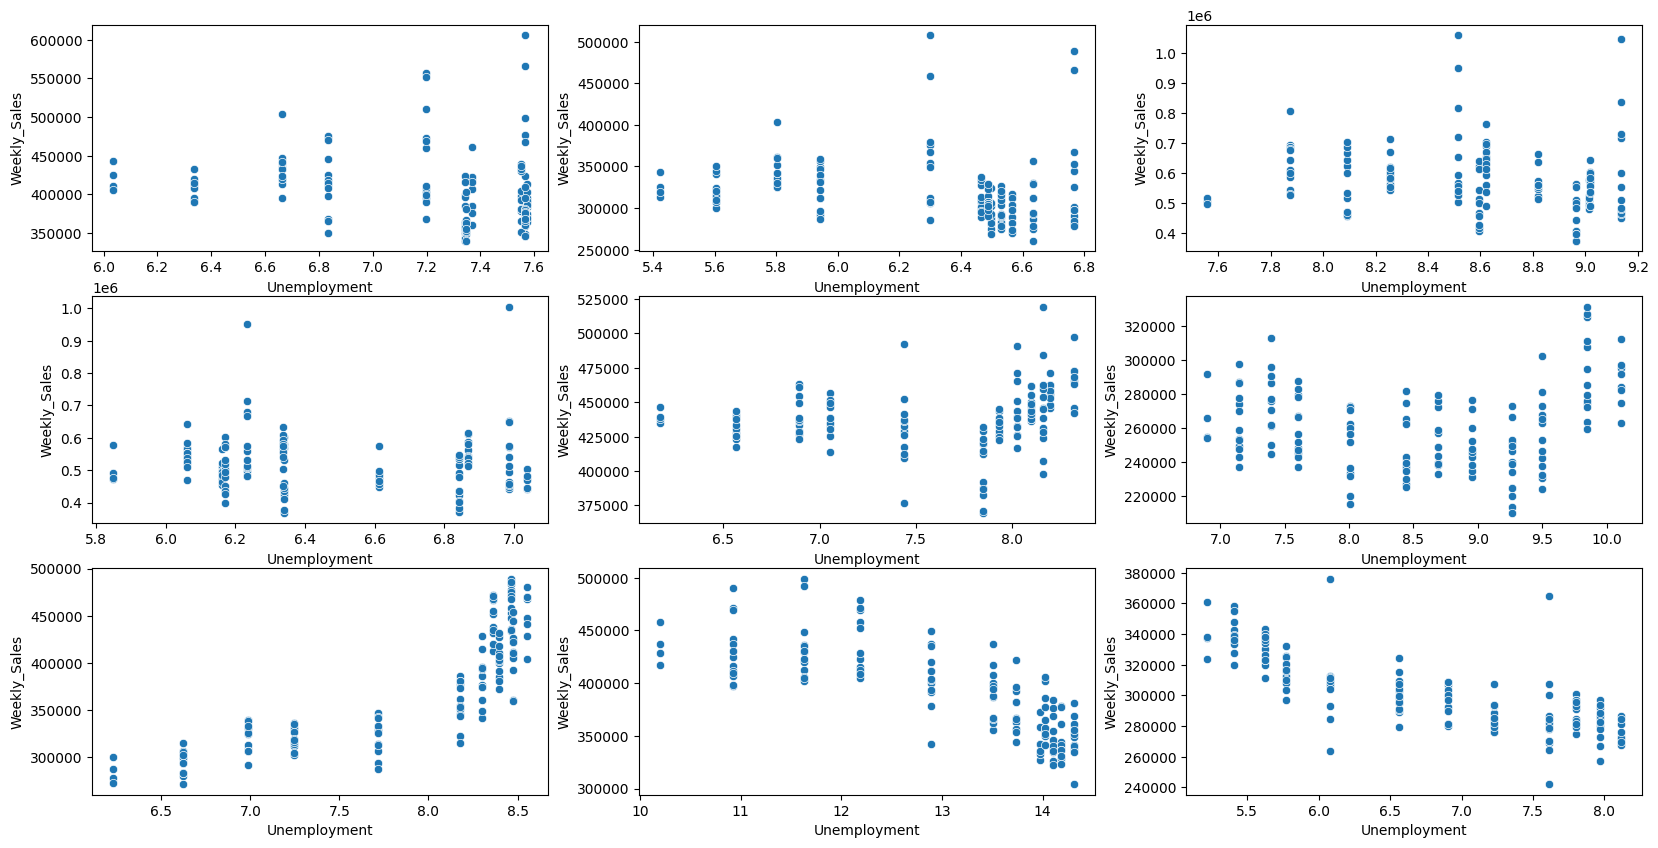

In [91]:
plt.figure(figsize=(20,10))

plt.subplot(3,3,1)
sns.scatterplot(data=Store[3],x='Unemployment',y='Weekly_Sales')
plt.subplot(3,3,2)
sns.scatterplot(data=Store[5],x='Unemployment',y='Weekly_Sales')
plt.subplot(3,3,3)
sns.scatterplot(data=Store[7],x='Unemployment',y='Weekly_Sales')
plt.subplot(3,3,4)
sns.scatterplot(data=Store[16],x='Unemployment',y='Weekly_Sales')
plt.subplot(3,3,5)
sns.scatterplot(data=Store[30],x='Unemployment',y='Weekly_Sales')
plt.subplot(3,3,6)
sns.scatterplot(data=Store[33],x='Unemployment',y='Weekly_Sales')
plt.subplot(3,3,7)
sns.scatterplot(data=Store[36],x='Unemployment',y='Weekly_Sales')
plt.subplot(3,3,8)
sns.scatterplot(data=Store[38],x='Unemployment',y='Weekly_Sales')
plt.subplot(3,3,9)
sns.scatterplot(data=Store[44],x='Unemployment',y='Weekly_Sales')

##### Sales Decrease as unemployment increases, store 38 and 44 has most effect of unemployment.

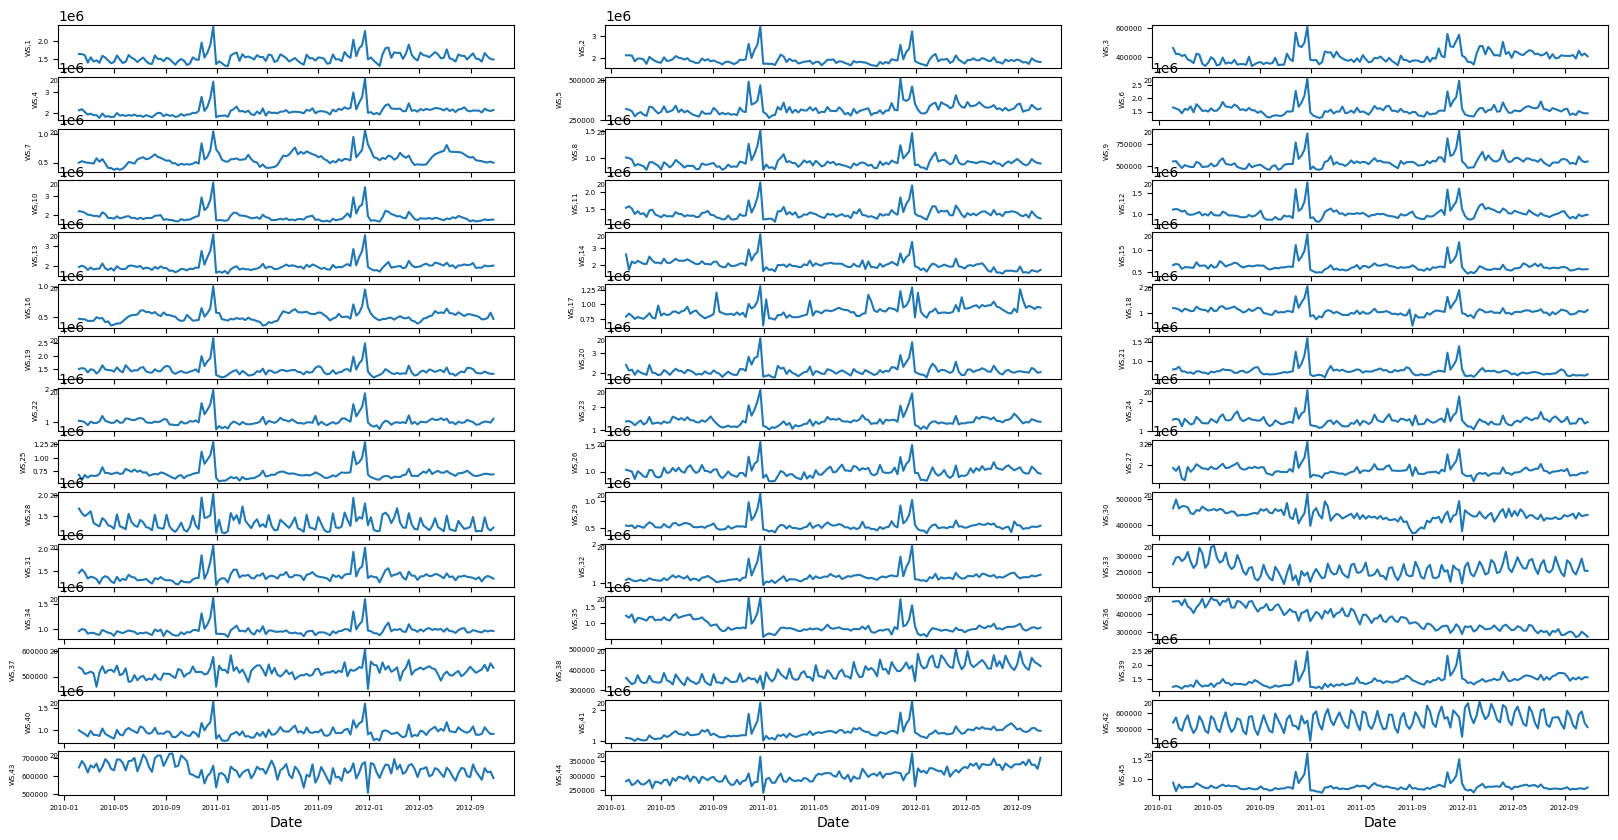

In [92]:
plt.figure(figsize=(20,10))

for i in range(1,46):
    plt.subplot(15,3,i)
    sns.lineplot(data=Store[i],x='Date',y='Weekly_Sales')
    plt.ylabel(f'WS,{i}', size = 5)
    plt.xticks(size = 5)
    plt.yticks(size = 5)

##### Most of the stores shows similar seasonality peak of sales on holidays and consistency except a few.

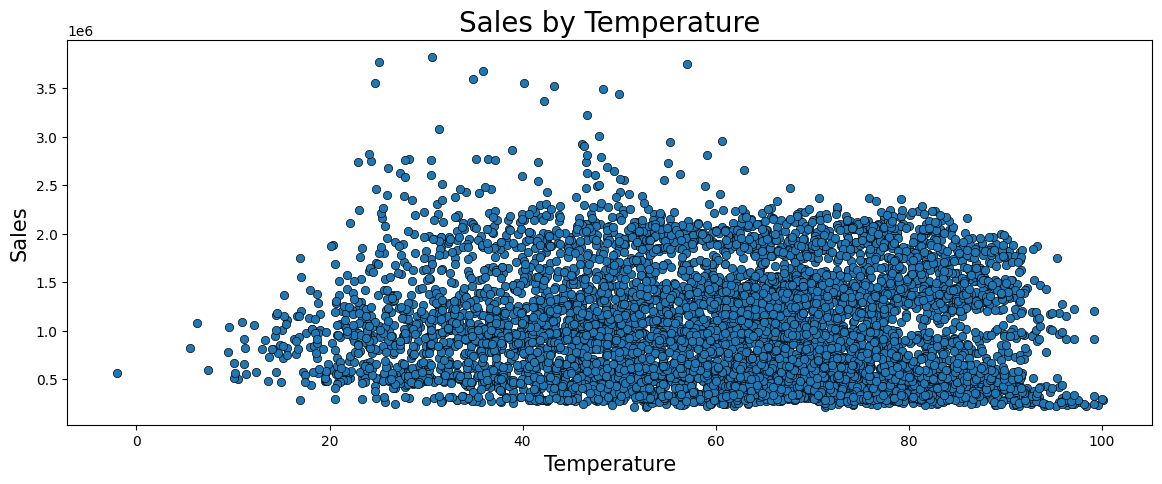

In [93]:
plt.figure(figsize = (14, 5))
sns.scatterplot(data = df,
                x = 'Temperature',
                y = 'Weekly_Sales',
                edgecolor = "black")

# Add labels and title
plt.title('Sales by Temperature', size = 20)
plt.xlabel('Temperature', size = 15)
plt.ylabel('Sales', size = 15)
plt.show()

### Sales not seem to be affected by temperature

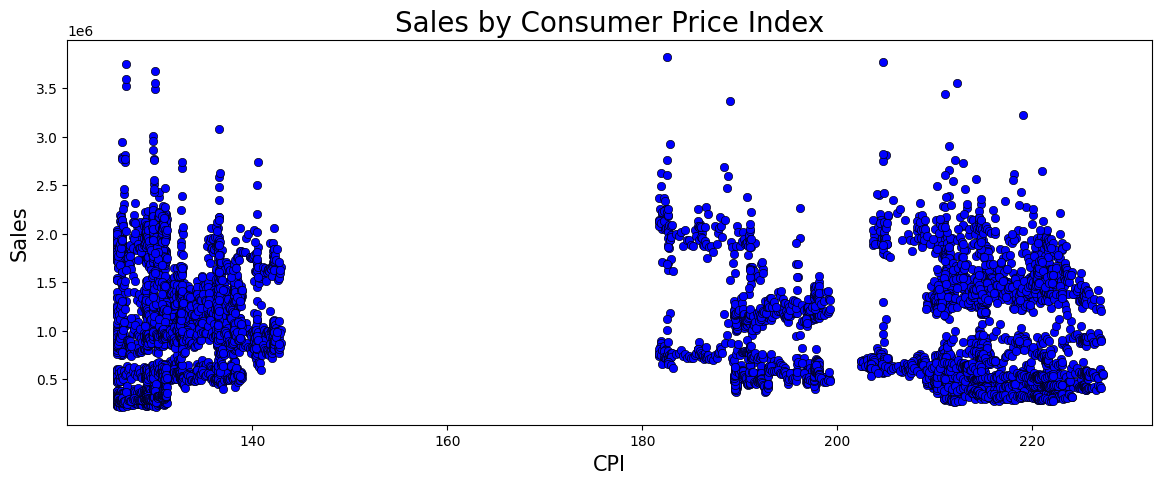

In [94]:
plt.figure(figsize = (14, 5))
sns.scatterplot(data = df,
                x = 'CPI',
                y = 'Weekly_Sales',
                color = 'blue',
                edgecolor = "black")

# Add labels and title
plt.title('Sales by Consumer Price Index', size = 20)
plt.xlabel('CPI', size = 15)
plt.ylabel('Sales', size = 15)
plt.show()

### CPI seems to have a little effect as these can be segment in different classes of consumers, and in all three sales decrease as CPI increase.

In [95]:
Top_5_stores = total_sales.sort_values(ascending=False).head(5)
Top_5_stores 

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
Name: Weekly_Sales, dtype: float64

In [96]:
last_5_stores = total_sales.sort_values(ascending=True).head(5)
last_5_stores 

Store
33    37160221.96
44    43293087.84
5     45475688.90
36    53412214.97
38    55159626.42
Name: Weekly_Sales, dtype: float64

#### Top 5 performing stores are 20,4,14,13 and 2 in terms of total sales
#### Worst 5 performing stores are  33,44,5,36 and 38 in terms of total sales

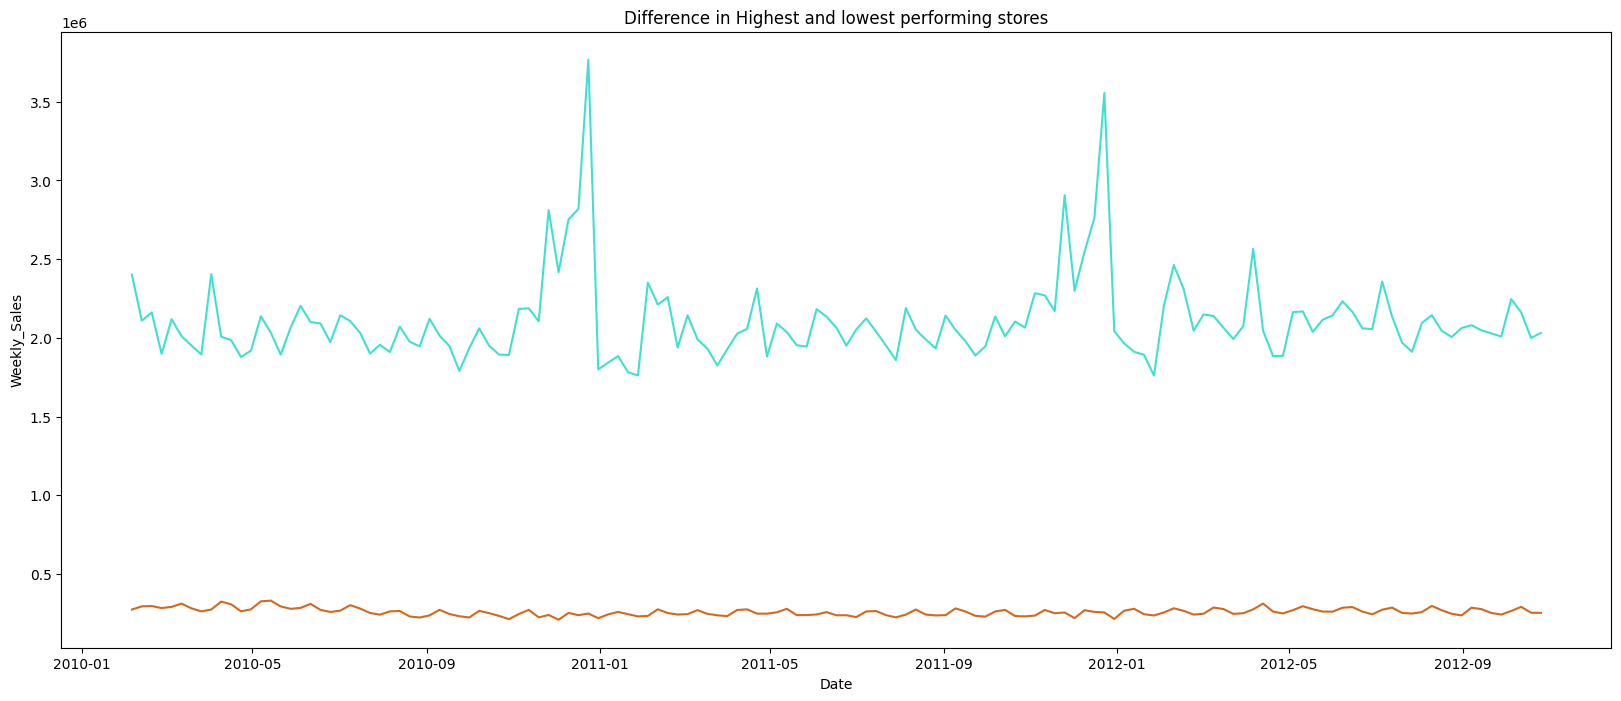

In [97]:
plt.figure(figsize=(20,8))
sns.lineplot(data=Store[20],x='Date',y='Weekly_Sales',color = 'turquoise')
sns.lineplot(data=Store[33],x='Date',y='Weekly_Sales',color = 'chocolate')
plt.ylabel('Weekly_Sales')
plt.title('Difference in Highest and lowest performing stores')
plt.show()

# Modeling 

In [98]:
# checking stationarity of series
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose # visual representation of seasonal decompose
from statsmodels.tsa.stattools import acf,pacf# plotting acf and pacf graph
from statsmodels.tsa.arima_model import ARIMA #modelling

In [99]:
Store[20]

,index,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,2717,20,2010-02-05,2401395.47,0,25.92,2.784,204.247194,8.187
1,2718,20,2010-02-12,2109107.90,1,22.12,2.773,204.385747,8.187
2,2719,20,2010-02-19,2161549.76,0,25.43,2.745,204.432100,8.187
3,2720,20,2010-02-26,1898193.95,0,32.32,2.754,204.463087,8.187
4,2721,20,2010-03-05,2119213.72,0,31.75,2.777,204.494073,8.187
...,...,...,...,...,...,...,...,...,...
138,2855,20,2012-09-28,2008350.58,0,58.65,3.997,215.736716,7.280
139,2856,20,2012-10-05,2246411.89,0,60.77,3.985,215.925886,7.293
140,2857,20,2012-10-12,2162951.36,0,47.20,4.000,216.115057,7.293
141,2858,20,2012-10-19,1999363.49,0,56.26,3.969,216.146470,7.293


In [100]:
for store_num in range(1,df['Store'].nunique()+1):
    result = adfuller(Store[store_num]['Weekly_Sales'])
    p_value = result[1]
    if(p_value<0.05):
        print(f'Store{store_num} : {p_value}  : Stationary')
    else:        
        print(f'Store{store_num} : {p_value}  : Non - Stationary') 

Store1 : 1.3877788330759307e-05  : Stationary
Store2 : 0.0039902070890663124  : Stationary
Store3 : 0.03840926179831256  : Stationary
Store4 : 0.04779866223669852  : Stationary
Store5 : 0.00042517056141923656  : Stationary
Store6 : 2.1594858682169855e-06  : Stationary
Store7 : 0.0002170071890711761  : Stationary
Store8 : 1.0027464429004956e-06  : Stationary
Store9 : 2.134309368938939e-05  : Stationary
Store10 : 8.763067535583776e-06  : Stationary
Store11 : 0.0033168367374902708  : Stationary
Store12 : 1.0451838349619274e-06  : Stationary
Store13 : 2.05644619369346e-06  : Stationary
Store14 : 0.06786986708375134  : Non - Stationary
Store15 : 1.5100158829353333e-06  : Stationary
Store16 : 0.00017660674414720636  : Stationary
Store17 : 5.679177242072978e-06  : Stationary
Store18 : 0.006006639324913575  : Stationary
Store19 : 1.1614730793254024e-06  : Stationary
Store20 : 3.4912952838128635e-06  : Stationary
Store21 : 2.1593822298552223e-06  : Stationary
Store22 : 8.09284158835205e-08  : S

#### As Some values of p is greater than 0.05, Every Stores data is not Stationary.
#### Differencing to make the data Stationary

In [101]:
## Differencing
for store_num in range(1,df['Store'].nunique()+1):
    Store[store_num].Weekly_Sales = Store[store_num].Weekly_Sales.diff()
Store[20]

,index,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,2717,20,2010-02-05,NaN,0,25.92,2.784,204.247194,8.187
1,2718,20,2010-02-12,-292287.57,1,22.12,2.773,204.385747,8.187
2,2719,20,2010-02-19,52441.86,0,25.43,2.745,204.432100,8.187
3,2720,20,2010-02-26,-263355.81,0,32.32,2.754,204.463087,8.187
4,2721,20,2010-03-05,221019.77,0,31.75,2.777,204.494073,8.187
...,...,...,...,...,...,...,...,...,...
138,2855,20,2012-09-28,-20236.66,0,58.65,3.997,215.736716,7.280
139,2856,20,2012-10-05,238061.31,0,60.77,3.985,215.925886,7.293
140,2857,20,2012-10-12,-83460.53,0,47.20,4.000,216.115057,7.293
141,2858,20,2012-10-19,-163587.87,0,56.26,3.969,216.146470,7.293


In [102]:
# Dropping Null Values
for store_num in range(1,df['Store'].nunique()+1):
    Store[store_num] = Store[store_num].dropna().reset_index()

#### Checking for Stationarity again..

In [103]:
for store_num in range(1,df['Store'].nunique()+1):
    result = adfuller(Store[store_num]['Weekly_Sales'])
    p_value = result[1]
    if(p_value<0.05):
        print(f'Store{store_num} : {p_value}  : Stationary')
    else:        
        print(f'Store{store_num} : {p_value}  : Non - Stationary') 

Store1 : 1.6761796699229161e-10  : Stationary
Store2 : 1.429769715927088e-12  : Stationary
Store3 : 1.1531676337938207e-09  : Stationary
Store4 : 7.995678269052111e-10  : Stationary
Store5 : 1.0722213925859083e-09  : Stationary
Store6 : 5.656318178504453e-06  : Stationary
Store7 : 1.2040696621488704e-06  : Stationary
Store8 : 2.948481763403726e-10  : Stationary
Store9 : 2.18130569229703e-10  : Stationary
Store10 : 4.393504125991289e-09  : Stationary
Store11 : 7.401059688624081e-10  : Stationary
Store12 : 4.5857560575406544e-10  : Stationary
Store13 : 4.459828693277224e-11  : Stationary
Store14 : 8.464371616908959e-11  : Stationary
Store15 : 8.07020165229342e-09  : Stationary
Store16 : 2.313024178712324e-08  : Stationary
Store17 : 0.001055853886501208  : Stationary
Store18 : 4.77626714650186e-12  : Stationary
Store19 : 9.447145592096314e-12  : Stationary
Store20 : 8.831131109477106e-12  : Stationary
Store21 : 5.438761165452764e-10  : Stationary
Store22 : 3.0786192971231276e-11  : Statio

#### p_value <0.05 , All Stores Data is now Stationary

<Figure size 640x480 with 0 Axes>

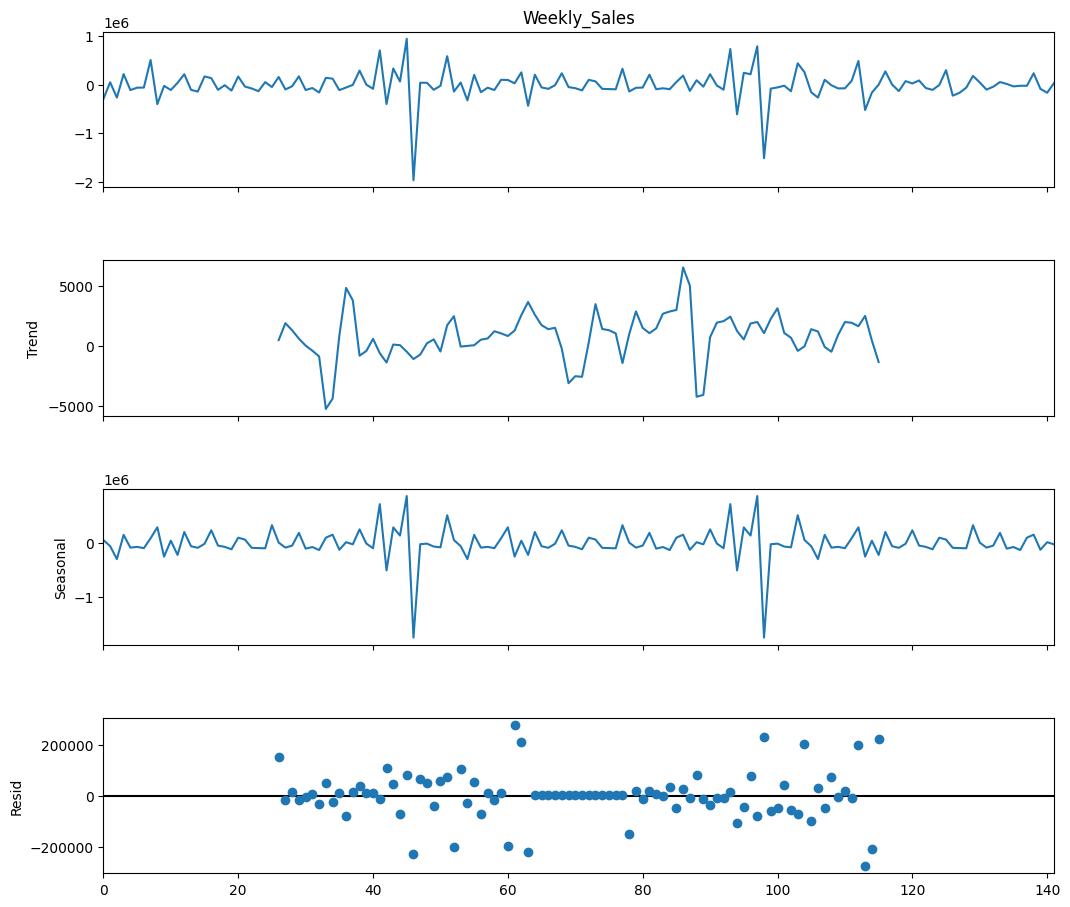

In [104]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(Store[20].Weekly_Sales, period=52)  
fig = plt.figure()  
fig = decomposition.plot()  
fig.set_size_inches(12, 10)
plt.show()

##### There isn't much trend in the dataset, Seasonality can be seen as the sales peak at holidays

In [105]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

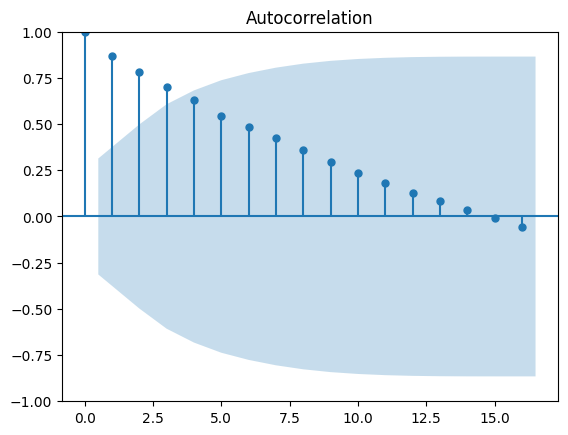

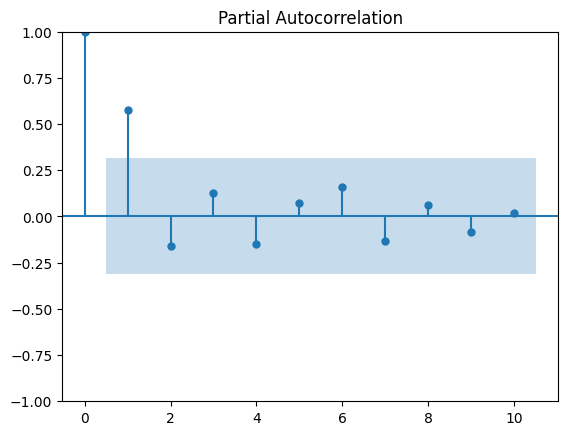

In [106]:
acf_plot=acf(df['Weekly_Sales'])
pacf_plot=pacf(df['Weekly_Sales'])
plot_acf(acf_plot);
plot_pacf(pacf_plot,lags=10);

#### Using Sarima model to capture the seasonality for prediction of 12 weeks sales.

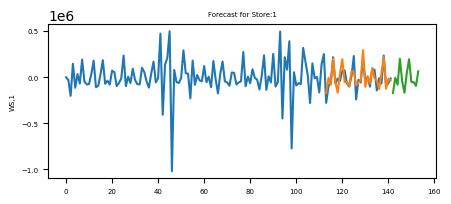

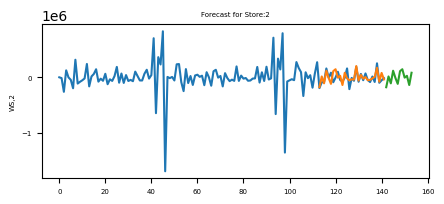

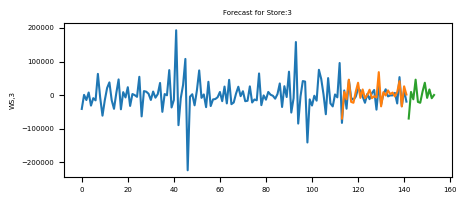

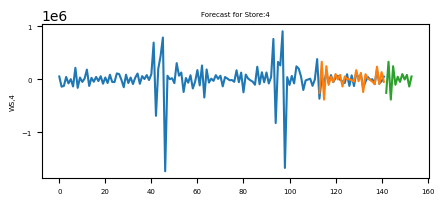

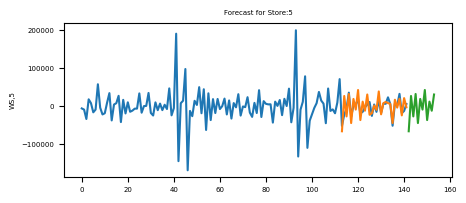

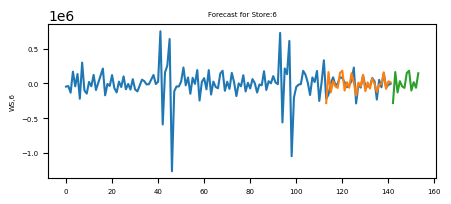

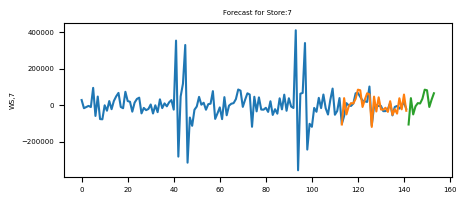

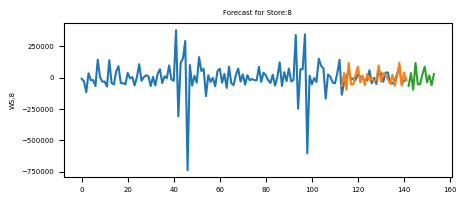

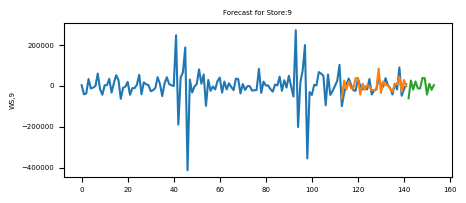

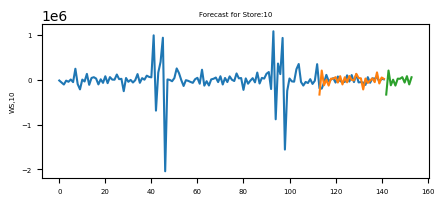

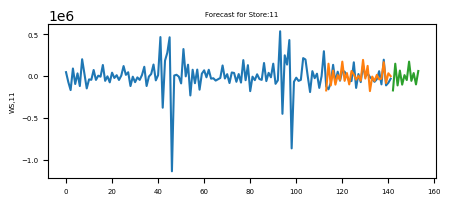

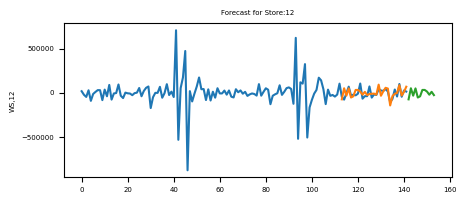

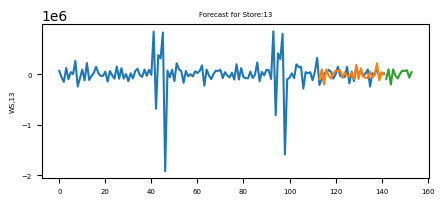

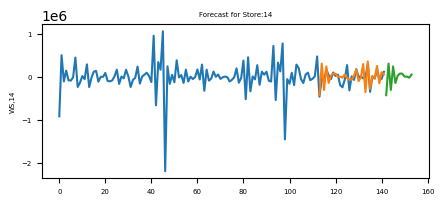

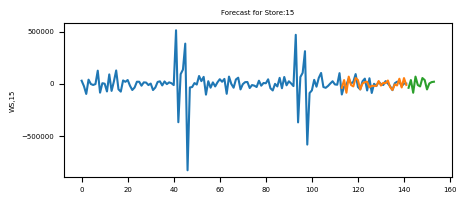

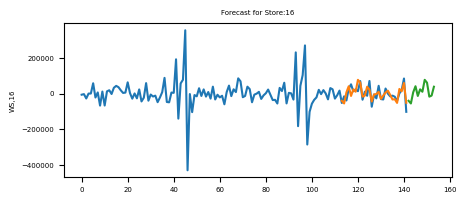

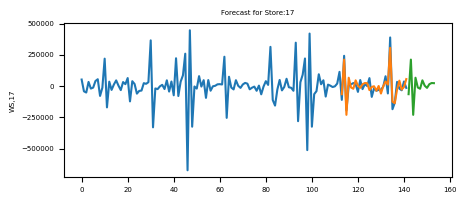

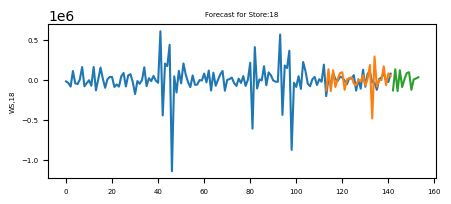

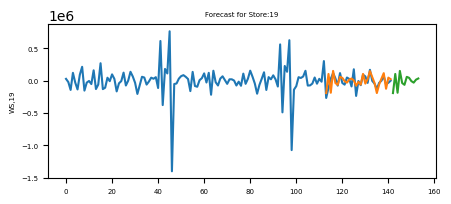

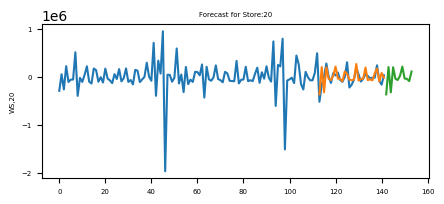

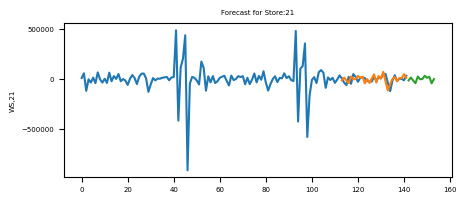

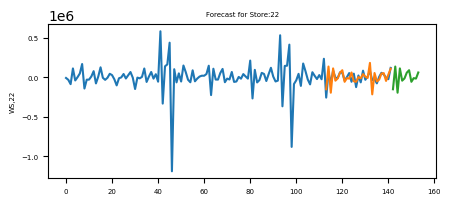

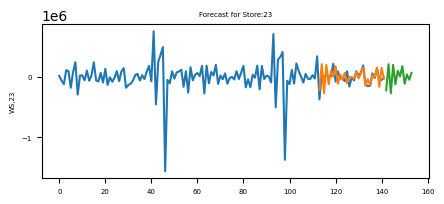

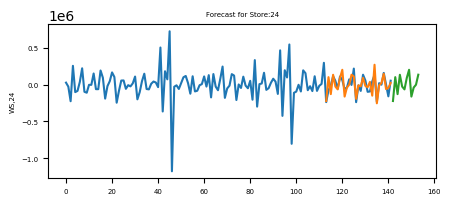

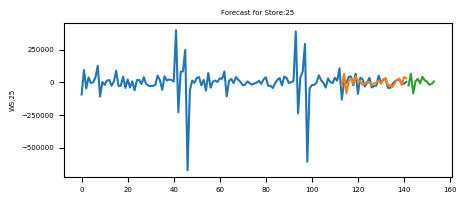

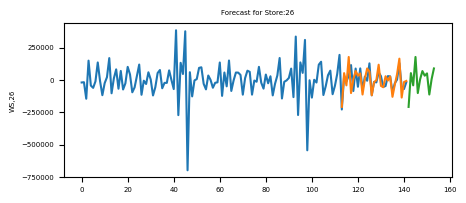

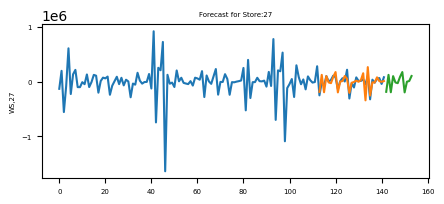

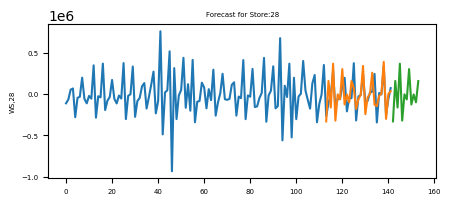

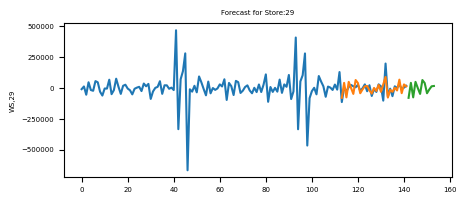

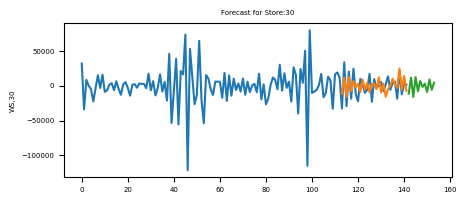

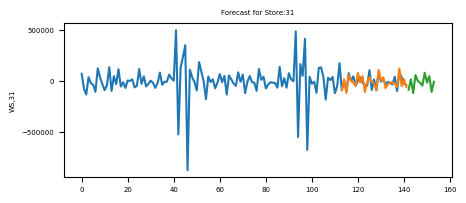

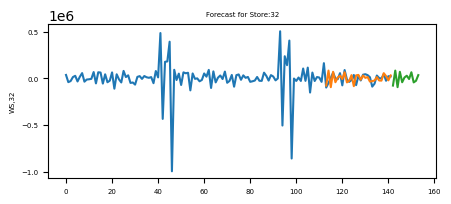

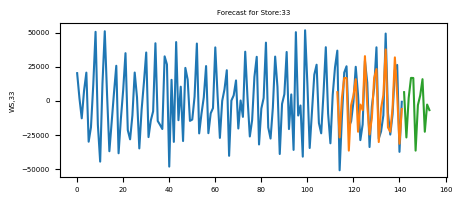

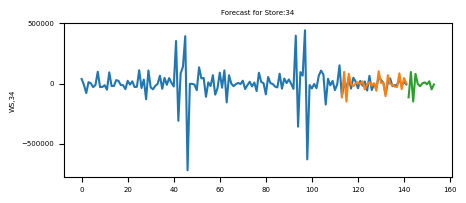

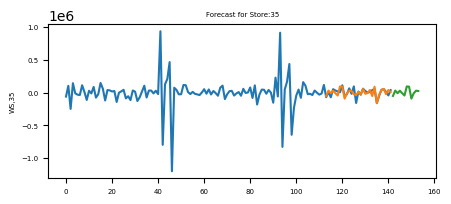

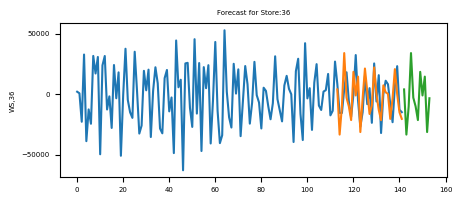

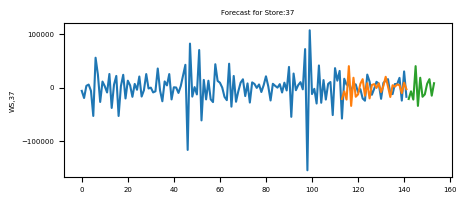

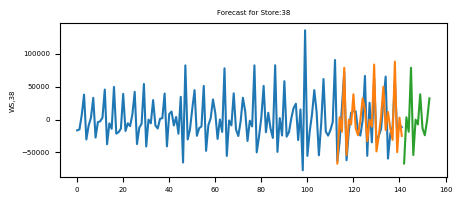

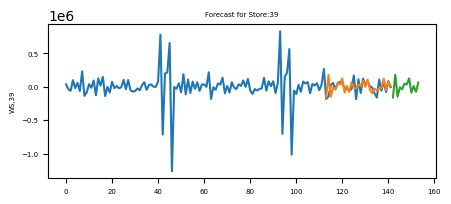

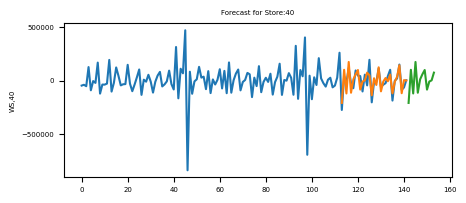

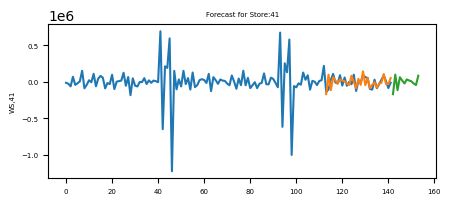

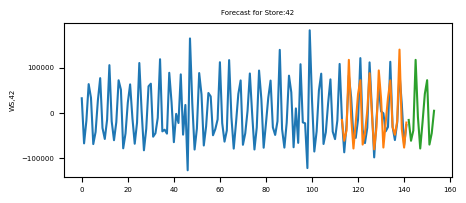

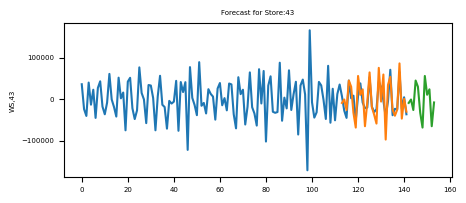

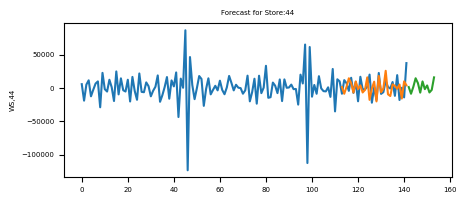

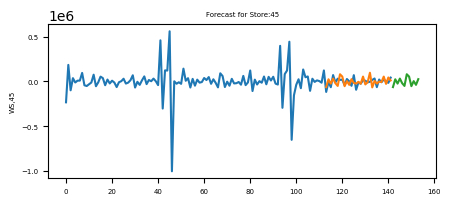

In [107]:
import statsmodels.api as sm
ratio = 0.8
for store_num in range(1,df['Store'].nunique()+1):
    
    train_size = Store[store_num].shape[0]
    train_size = int(train_size*ratio)
    train = Store[store_num].iloc[:train_size]['Weekly_Sales']
    test = Store[store_num].iloc[train_size:]['Weekly_Sales'] 

    model = sm.tsa.statespace.SARIMAX(train,
                                order=(1, 1, 3),
                                seasonal_order=(1, 1, 1, 52),  
                                enforce_invertibility=False)
    model_fit = model.fit()

    Store[store_num]['predict'] = model_fit.predict(start=len(train),end=len(train)+len(test),dynamic=True)
    forecast = model_fit.forecast(steps=12)
    plt.figure(figsize=(5,2))
    plt.title(f'Forecast for Store:{store_num}', size = 5)
    plt.ylabel(f'WS,{store_num}', size = 5)
    plt.xticks(size = 5)
    plt.yticks(size = 5)
    plt.plot(Store[store_num]['Weekly_Sales'], label = 'Data')
    plt.plot(Store[store_num]['predict'], label = 'Predict')
    plt.plot(range(len(train)+len(test), len(train)+len(test)+len(forecast)),forecast, label = 'Forecast')
    plt.show()

### Conclusion
- There are no holiday seasons in next 12 weeks hence the sales will keep on regular amount.
- Some stores are performing great while some needs to implement some techniques to attract more customers.